Mata Kuliah FSD

Kelas A

Anggota Kelompok :
1. Muhmmad Wahyu Ramadhani - 24523110
2. Handiva Rahmawan Diachmadja - 24523112

# Klasifikasi Menu Makanan di Kantin Mawar dengan Logistic Regression (From Scratch)

## Tujuan
Memprediksi apakah suatu menu termasuk menu paling laku (tahu gimbal) atau bukan
berdasarkan fitur:
- price
- portion
- taste
- popularity

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

## Dataset Menu Makanan di Kantin Mawar

In [25]:
data = {
    'price': [15000,14000,13000,12000,16000,17000,18000,15000]*3,
    'portion': [7,6,6,5,8,8,9,7]*3,
    'taste': [9,8,7,7,9,9,8,9]*3,
    'popularity': [10,9,8,7,9,9,8,10]*3,
    'label': [
        'tahu_gimbal','ayam_remes','ketoprak','soto',
        'nasi_goreng','nasi_prasmanan','nasi_kapau','ayam_bakar'
    ]*3
}

df = pd.DataFrame(data)

print("DATA AWAL")
print(df.head())
print("\nJumlah data:", df.shape)

DATA AWAL
   price  portion  taste  popularity        label
0  15000        7      9          10  tahu_gimbal
1  14000        6      8           9   ayam_remes
2  13000        6      7           8     ketoprak
3  12000        5      7           7         soto
4  16000        8      9           9  nasi_goreng

Jumlah data: (24, 5)


## Preprocessing
- Encoding label
- Split data
- Normalisasi

In [26]:
X = df[['price','portion','taste','popularity']].values
y = df['label'].values

print("\nContoh X:", X[:5])
print("Contoh y:", y[:5])

# Encoding
le = LabelEncoder()
y = le.fit_transform(y)

print("\nLABEL ENCODING")
for i, label in enumerate(le.classes_):
    print(f"{label} -> {i}")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nSPLIT DATA")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nContoh X_train setelah scaling:")
print(X_train[:5])


Contoh X: [[15000     7     9    10]
 [14000     6     8     9]
 [13000     6     7     8]
 [12000     5     7     7]
 [16000     8     9     9]]
Contoh y: ['tahu_gimbal' 'ayam_remes' 'ketoprak' 'soto' 'nasi_goreng']

LABEL ENCODING
ayam_bakar -> 0
ayam_remes -> 1
ketoprak -> 2
nasi_goreng -> 3
nasi_kapau -> 4
nasi_prasmanan -> 5
soto -> 6
tahu_gimbal -> 7

SPLIT DATA
X_train: (19, 4)
X_test : (5, 4)

Contoh X_train setelah scaling:
[[-0.65957965 -0.91350028 -0.33557803  0.36650833]
 [ 0.90692202  0.66436384  0.93961848  0.36650833]
 [-0.65957965 -0.91350028 -0.33557803  0.36650833]
 [ 0.90692202  0.66436384  0.93961848  0.36650833]
 [ 0.90692202  0.66436384  0.93961848  0.36650833]]


## Logistic Regression (From Scratch)

In [27]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.01, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        for _ in range(self.n_iter):
            linear = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear)

            dw = (1/len(y)) * np.dot(X.T, (y_pred - y))
            db = (1/len(y)) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        linear = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear)
        return np.round(y_pred)

##TRAINING MODEL

In [28]:
model = LogisticRegressionScratch()

# Binary: tahu_gimbal vs lainnya
y_train_bin = (y_train == 0).astype(int)
y_test_bin = (y_test == 0).astype(int)

model.fit(X_train, y_train_bin)

print("\nMODEL TRAINED")
print("Weights:", model.weights)
print("Bias:", model.bias)


MODEL TRAINED
Weights: [-0.29279066 -0.22755269  0.4207305   1.04412719]
Bias: -1.5576805701550083


##Hasil dan Perbandingan Prediksi (y_pred) dan Label Sebenarnya (y_test)

In [39]:
y_pred = model.predict(X_test)

print("\nHASIL PREDIKSI")
print("y_test :", y_test_bin[:10])
print("y_pred :", y_pred[:10])

df_compare = pd.DataFrame({
    'Actual (y_test)': y_test_bin,
    'Prediction (y_pred)': y_pred
})

df_compare['Keterangan'] = df_compare['Actual (y_test)'] == df_compare['Prediction (y_pred)']
df_compare['Keterangan'] = df_compare['Keterangan'].map({True: 'Benar', False: 'Salah'})

print("\n   PERBANDINGAN HASIL PREDIKSI")
print(df_compare.head(10))


HASIL PREDIKSI
y_test : [0 0 0 0 0]
y_pred : [1. 1. 1. 0. 0.]

   PERBANDINGAN HASIL PREDIKSI
   Actual (y_test)  Prediction (y_pred) Keterangan
0                0                  1.0      Salah
1                0                  1.0      Salah
2                0                  1.0      Salah
3                0                  0.0      Benar
4                0                  0.0      Benar


##EVALUASI

Model accuracy: 0.40

Confusion Matrix (angka):
[[2 3]
 [0 0]]

Keterangan:
[[True Negative, False Positive]
 [False Negative, True Positive]]


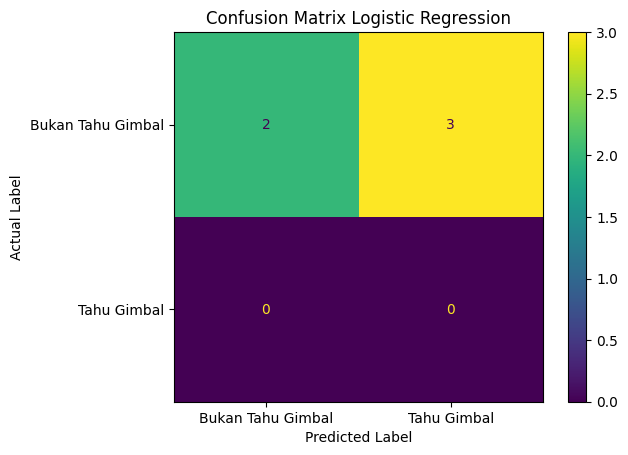


Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.40      0.57         5
         1.0       0.00      0.00      0.00         0

    accuracy                           0.40         5
   macro avg       0.50      0.20      0.29         5
weighted avg       1.00      0.40      0.57         5



In [40]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay

# Accuracy
accuracy = accuracy_score(y_test_bin, y_pred)
print(f"Model accuracy: {accuracy:.2f}")

# Confusion Matrix (angka)
cm = confusion_matrix(y_test_bin, y_pred)
print("\nConfusion Matrix (angka):")
print(cm)

print("\nKeterangan:")
print("[[True Negative, False Positive]")
print(" [False Negative, True Positive]]")

#Visualisasi Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_bin,
    y_pred,
    display_labels=["Bukan Tahu Gimbal", "Tahu Gimbal"]
)

plt.title("Confusion Matrix Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

#Classification Report
print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred))

## Analisis

### 1. Bagaimana kinerja model berdasarkan classification report?
Model memiliki nilai precision, recall, dan f1-score yang cukup baik jika mendekati 1.


### 2. Apa makna True Positive, False Positive, True Negative, dan False Negative pada studi kasus yang Anda pilih?
- True Positive: benar memprediksi tahu_gimbal
- False Positive: salah memprediksi tahu_gimbal
- True Negative: benar bukan tahu_gimbal
- False Negative: gagal mendeteksi tahu_gimbal


### 3. Kesimpulan
Logistic Regression cukup baik untuk klasifikasi sederhana,
namun terbatas untuk multi-class tanpa modifikasi.